## ***Model Loading***

In [ ]:
import os
import torch
from model.evaluation import evaluate_bleu
from model.generation import image_caption
from model.trainer import  flick , vocab_size
from model.model import encoder_decoder
from model.trainer import test_dataset

device = "cuda"  if torch.cuda.is_available() else "cpu"

model=encoder_decoder(em_size=712,
                            hidden_size=712,
                            expand_scale=2,
                            vocab_size=vocab_size,
                            num_expert=3,
                            max_length=1000,
                            num_head=8,
                            head_dim=712,
                            num_layers=4,
                            dropout_size=0.2
                      ).to(device)

# loading the checkpoint

if os.path.exists(f"checkpoints/checkpoint_9.pth"):
    checkpoint = torch.load(f"checkpoints/checkpoint_9.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

print("\n the model loaded \n\n")




 the model loaded 




## ***Evaluation***

In [22]:

print("*Evaluation*: \n")

bl1,bl4=evaluate_bleu(model, test_dataset, flick, device="cuda", max_examples=None , confidance=.5)

print(f'bl1:{bl1}')
print(f'bl4:{bl4}')

*Evaluation*: 

The early layer  for the token : [two] is : the Layer [2] and it's exit probability is [0.5248539447784424] 
The early layer  for the token : [men] is : the Layer [-1] and it's exit probability is [0.4627557098865509] 
The early layer  for the token : [are] is : the Layer [-1] and it's exit probability is [0.24750161170959473] 
The early layer  for the token : [posing] is : the Layer [-1] and it's exit probability is [0.28938812017440796] 
The early layer  for the token : [with] is : the Layer [-1] and it's exit probability is [0.44233113527297974] 
The early layer  for the token : [a] is : the Layer [1] and it's exit probability is [0.5026085376739502] 
The early layer  for the token : [camera] is : the Layer [3] and it's exit probability is [0.5212758183479309] 
The early layer  for the token : [in] is : the Layer [1] and it's exit probability is [0.5266801714897156] 
The early layer  for the token : [front] is : the Layer [1] and it's exit probability is [0.518343985

## **Testing the model**

The early layer  for the token : [a] is : the Layer [0] and it's exit probability is [0.8205416202545166] 
The early layer  for the token : [dog] is : the Layer [0] and it's exit probability is [0.6028121709823608] 
The early layer  for the token : [is] is : the Layer [-1] and it's exit probability is [0.33154991269111633] 
The early layer  for the token : [jumping] is : the Layer [-1] and it's exit probability is [0.4904484152793884] 
The early layer  for the token : [up] is : the Layer [0] and it's exit probability is [0.5097419023513794] 
The early layer  for the token : [at] is : the Layer [0] and it's exit probability is [0.6248595118522644] 
The early layer  for the token : [the] is : the Layer [0] and it's exit probability is [0.6640698909759521] 
The early layer  for the token : [beach] is : the Layer [0] and it's exit probability is [0.6714266538619995] 


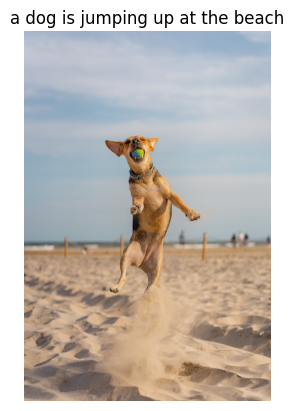

a dog is jumping up at the beach


In [29]:
print(image_caption(model=model,full_image_path='test_images/vertical-closeup-shot-companion-dog-catching-ball-while-running-sand.jpg',vocab=flick.vocab.W2i,max_length=40 , confidance= .5))


In [3]:
print(f"The number of trained parameters {sum(p.numel() for p in model.parameters() if p.requires_grad)} ")



The number of trained parameters 186900663 
